In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
PROJECT_ROOT = Path.cwd().parent

processed_dir = PROJECT_ROOT / "data" / "processed"

X_train = pd.read_csv(processed_dir / "X_train.csv")
X_val = pd.read_csv(processed_dir / "X_val.csv")
X_test = pd.read_csv(processed_dir / "X_test.csv")

y_train = pd.read_csv(
    processed_dir / "y_train.csv"
).squeeze("columns")

y_val = pd.read_csv(
    processed_dir / "y_val.csv"
).squeeze("columns")

y_test = pd.read_csv(
    processed_dir / "y_test.csv"
).squeeze("columns")

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (177576, 21)
Validation: (38052, 21)
Test: (38052, 21)


In [3]:
binary_features = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex",
]

ordinal_features = [
    "GenHlth",
    "Age",
    "Education",
    "Income",
]

count_features = [
    "MentHlth",
    "PhysHlth",
]

continuous_features = [
    "BMI",
]

numeric_features = (
    ordinal_features
    + count_features
    + continuous_features
)

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        ),
    ],
    remainder="drop"
)

In [5]:
def evaluate_model(model, X, y, model_name="Model"):

    predictions = model.predict(X)
    probabilities = model.predict_proba(X)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y, predictions),
        "Precision": precision_score(y, predictions, zero_division=0),
        "Recall": recall_score(y, predictions, zero_division=0),
        "F1 Score": f1_score(y, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y, probabilities),
        "PR-AUC": average_precision_score(y, probabilities),
    }

    return results

In [6]:
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

logistic_results = evaluate_model(
    logistic_model,
    X_val,
    y_val,
    "Logistic Regression"
)

logistic_results

c:\Users\dell\Desktop\Personal projects\Hackathon Project\Machine_Learning_Model\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'Model': 'Logistic Regression',
 'Accuracy': 0.7301850099863345,
 'Precision': 0.30952198265940306,
 'Recall': 0.7608449641644662,
 'F1 Score': 0.4400327242977911,
 'ROC-AUC': 0.8214940408487652,
 'PR-AUC': 0.4020054947458287}

In [7]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=15,
                min_samples_split=10,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_results = evaluate_model(
    rf_model,
    X_val,
    y_val,
    "Random Forest"
)

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.7409334594765058,
 'Precision': 0.31816730523627074,
 'Recall': 0.7517917766880422,
 'F1 Score': 0.4471116096466629,
 'ROC-AUC': 0.824803032702624,
 'PR-AUC': 0.4225307870365196}

In [8]:
hgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.1,
                max_iter=200,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=42
            )
        )
    ]
)

hgb_model.fit(X_train, y_train)

hgb_results = evaluate_model(
    hgb_model,
    X_val,
    y_val,
    "HistGradientBoosting"
)

hgb_results

{'Model': 'HistGradientBoosting',
 'Accuracy': 0.8649479659413434,
 'Precision': 0.5535128036769534,
 'Recall': 0.15899660505469634,
 'F1 Score': 0.24703296703296704,
 'ROC-AUC': 0.8284269309291323,
 'PR-AUC': 0.4270133479137627}

In [9]:
results_df = pd.DataFrame([
    logistic_results,
    rf_results,
    hgb_results
])

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
1,Random Forest,0.7409,0.3182,0.7518,0.4471,0.8248,0.4225
0,Logistic Regression,0.7302,0.3095,0.7608,0.4400,0.8215,0.4020
2,HistGradientBoosting,0.8649,0.5535,0.1590,0.2470,0.8284,0.4270


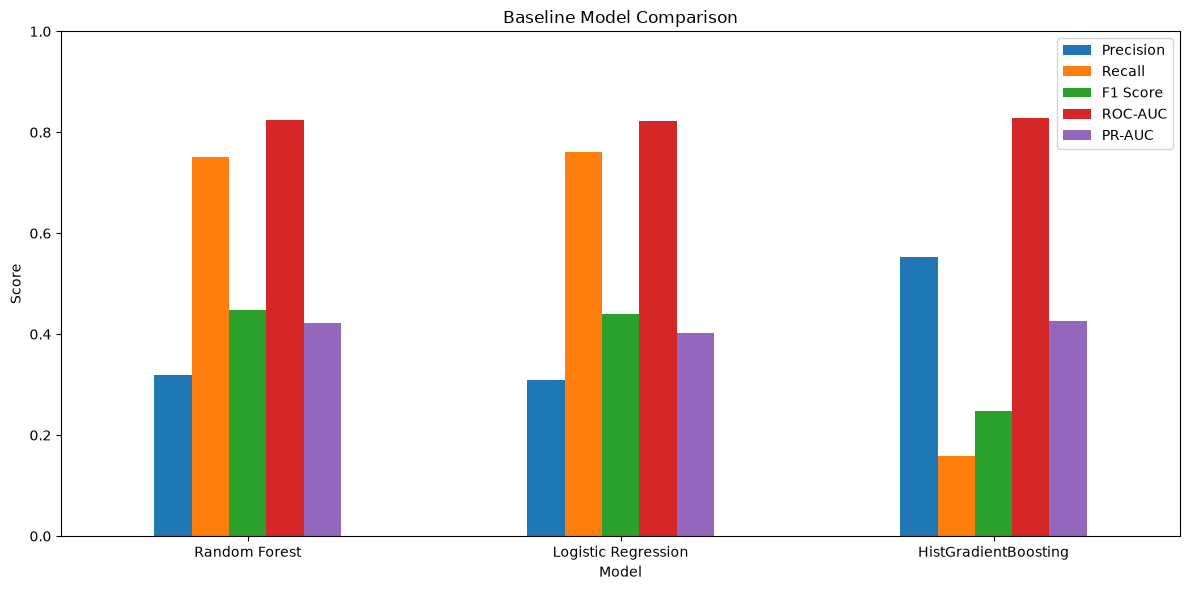

In [10]:
metrics_to_plot = [
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]

results_df.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

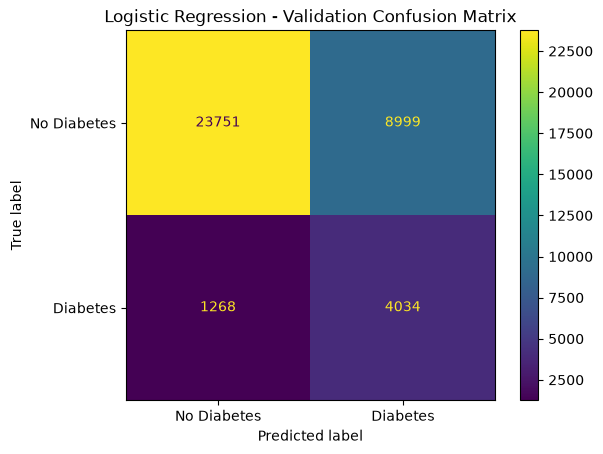

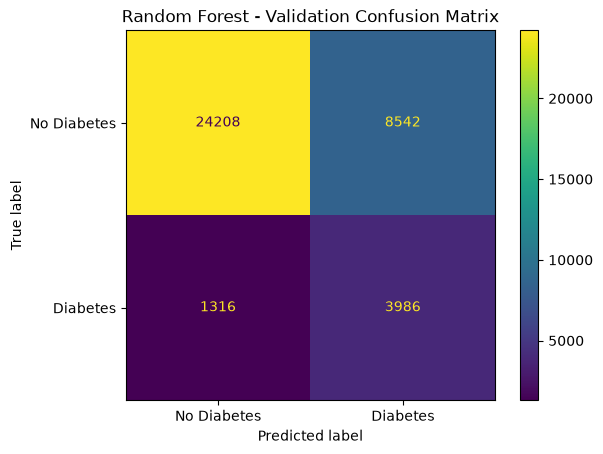

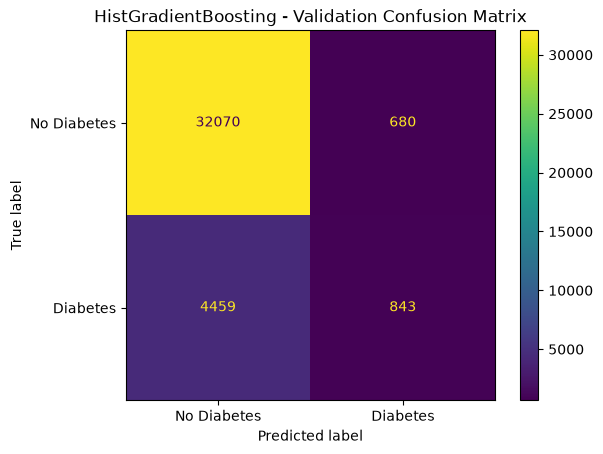

In [11]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "HistGradientBoosting": hgb_model
}

for name, model in models.items():

    predictions = model.predict(X_val)

    cm = confusion_matrix(y_val, predictions)

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Diabetes", "Diabetes"]
    )

    display.plot()

    plt.title(f"{name} - Validation Confusion Matrix")

    plt.show()

In [12]:
for name, model in models.items():

    predictions = model.predict(X_val)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_val,
            predictions,
            target_names=["No Diabetes", "Diabetes"],
            digits=4
        )
    )

Logistic Regression
              precision    recall  f1-score   support

 No Diabetes     0.9493    0.7252    0.8223     32750
    Diabetes     0.3095    0.7608    0.4400      5302

    accuracy                         0.7302     38052
   macro avg     0.6294    0.7430    0.6312     38052
weighted avg     0.8602    0.7302    0.7690     38052

Random Forest
              precision    recall  f1-score   support

 No Diabetes     0.9484    0.7392    0.8308     32750
    Diabetes     0.3182    0.7518    0.4471      5302

    accuracy                         0.7409     38052
   macro avg     0.6333    0.7455    0.6390     38052
weighted avg     0.8606    0.7409    0.7774     38052

HistGradientBoosting
              precision    recall  f1-score   support

 No Diabetes     0.8779    0.9792    0.9258     32750
    Diabetes     0.5535    0.1590    0.2470      5302

    accuracy                         0.8649     38052
   macro avg     0.7157    0.5691    0.5864     38052
weighted avg     0.

In [13]:
def evaluate_thresholds(model, X, y, thresholds):

    probabilities = model.predict_proba(X)[:, 1]

    results = []

    for threshold in thresholds:

        predictions = (probabilities >= threshold).astype(int)

        results.append({
            "Threshold": threshold,
            "Precision": precision_score(
                y,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y,
                predictions,
                zero_division=0
            ),
            "F1 Score": f1_score(
                y,
                predictions,
                zero_division=0
            ),
            "Accuracy": accuracy_score(
                y,
                predictions
            )
        })

    return pd.DataFrame(results)

In [14]:
thresholds = np.arange(0.10, 0.71, 0.05)

hgb_threshold_results = evaluate_thresholds(
    hgb_model,
    X_val,
    y_val,
    thresholds
)

hgb_threshold_results.round(4)

,Threshold,Precision,Recall,F1 Score,Accuracy
0,0.10,0.2708,0.8618,0.4121,0.6574
1,0.15,0.3163,0.7722,0.4487,0.7357
2,0.20,0.3555,0.6716,0.4649,0.7846
3,0.25,0.3939,0.5817,0.4697,0.8170
4,0.30,0.4334,0.4955,0.4624,0.8395
5,0.35,0.4638,0.4002,0.4297,0.8520
6,0.40,0.4917,0.3142,0.3834,0.8592
7,0.45,0.5270,0.2299,0.3202,0.8639
8,0.50,0.5535,0.1590,0.2470,0.8649
9,0.55,0.5994,0.1081,0.1831,0.8657


In [15]:
best_hgb_threshold = hgb_threshold_results.loc[
    hgb_threshold_results["F1 Score"].idxmax()
]

best_hgb_threshold

Threshold    0.250000
Precision    0.393870
Recall       0.581667
F1 Score     0.469692
Accuracy     0.816987
Name: 3, dtype: float64

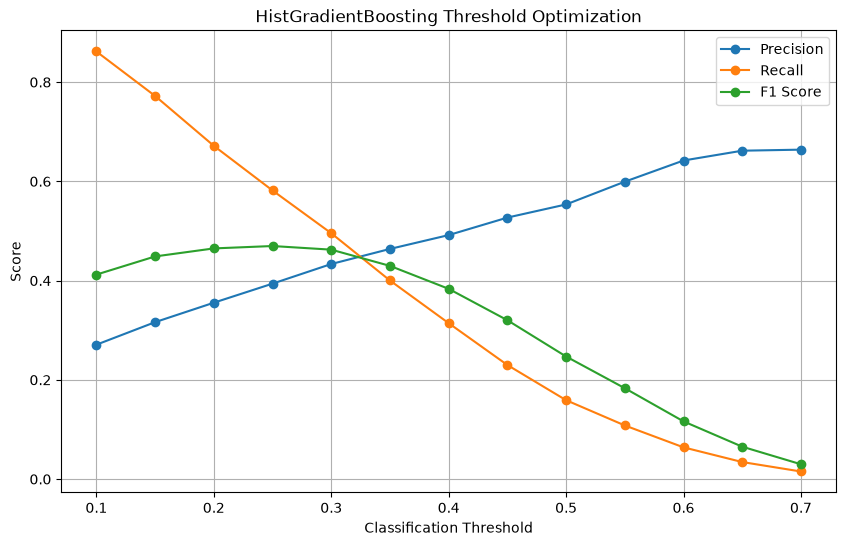

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    hgb_threshold_results["Threshold"],
    hgb_threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    hgb_threshold_results["Threshold"],
    hgb_threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    hgb_threshold_results["Threshold"],
    hgb_threshold_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("HistGradientBoosting Threshold Optimization")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
rf_threshold_results = evaluate_thresholds(
    rf_model,
    X_val,
    y_val,
    thresholds
)

rf_threshold_results.round(4)

,Threshold,Precision,Recall,F1 Score,Accuracy
0,0.10,0.1765,0.9864,0.2994,0.3567
1,0.15,0.1929,0.9745,0.3221,0.4284
2,0.20,0.2079,0.9602,0.3417,0.4846
3,0.25,0.2235,0.9404,0.3612,0.5366
4,0.30,0.2402,0.9163,0.3806,0.5844
5,0.35,0.2566,0.8893,0.3982,0.6255
6,0.40,0.2744,0.8536,0.4153,0.6651
7,0.45,0.2949,0.8086,0.4322,0.7040
8,0.50,0.3182,0.7518,0.4471,0.7409
9,0.55,0.3443,0.6952,0.4605,0.7730


In [18]:
best_rf_threshold = rf_threshold_results.loc[
    rf_threshold_results["F1 Score"].idxmax()
]

best_rf_threshold

Threshold    0.600000
Precision    0.372223
Recall       0.625802
F1 Score     0.466798
Accuracy     0.800799
Name: 10, dtype: float64

In [19]:
lr_threshold_results = evaluate_thresholds(
    logistic_model,
    X_val,
    y_val,
    thresholds
)

best_lr_threshold = lr_threshold_results.loc[
    lr_threshold_results["F1 Score"].idxmax()
]

best_lr_threshold

Threshold    0.600000
Precision    0.357077
Recall       0.653338
F1 Score     0.461774
Accuracy     0.787790
Name: 10, dtype: float64